## 画像マスの抽出

In [1]:
import cv2
filename = "../data/level1/sample.jpg"
img = cv2.imread(filename, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("FaileRd to load image: {:s}".format(filename))

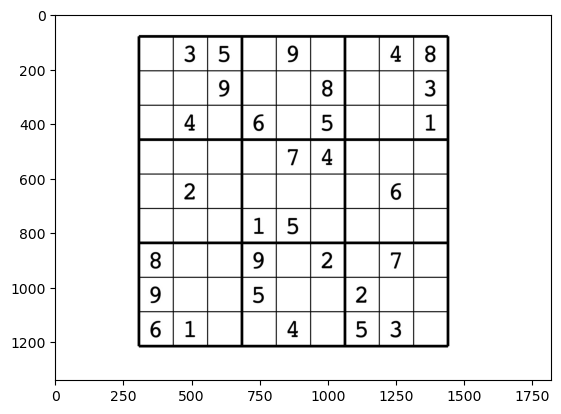

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.show()

In [2]:
import cv2
import numpy as np

# 二値データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
largest_contour = max(contours, key=cv2.contourArea)

# マス目の輪郭の四角を描く
x, y, w, h = cv2.boundingRect(largest_contour)

# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9
stepy = h // 9
for i in range(9):
    for j in range(9):
        cell = img[y + j*stepy:y + (j+1)*stepy, x + i*stepx:x + (i+1)*stepx]
        cell_images.append(cell)

# 例として、抽出したマス目の画像を保存
for idx, cell in enumerate(cell_images):
    cv2.imwrite(f"cell_{idx}.png", cell)


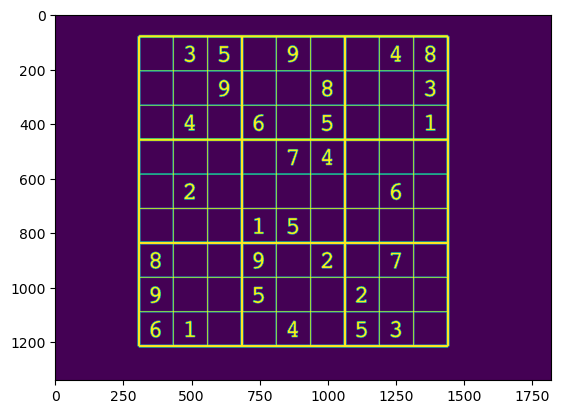

In [27]:
plt.imshow(thresh)
plt.show()

In [79]:
import cv2
import numpy as np

import cv2
filename = "../data/level1/sample.jpg"
img = cv2.imread(filename, cv2.IMREAD_COLOR)
if img is None:
    raise IOError("FaileRd to load image: {:s}".format(filename))

# 二値データに変換
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# # モルフォロジー変換を利用して細かい線を除去
# kernel = np.ones((3,3), np.uint8)
# thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

# 輪郭を見つける
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
largest_contour = max(contours, key=cv2.contourArea)

# マス目の輪郭の四角を描く
x, y, w, h = cv2.boundingRect(largest_contour)


# 各マス目の画像を抽出し、リストに保存
cell_images = []
stepx = w // 9 
stepy = h // 9
trim_size_x = stepx // 8  # ここでトリムするサイズを設定します。適宜調整してください。
trim_size_y = stepy // 8  # ここでトリムするサイズを設定します。適宜調整してください。

for i in range(9):
    for j in range(9):
        cell = img[y + j*stepy + trim_size_y : y + (j+1)*stepy - trim_size_y,
               x + i*stepx + trim_size_x : x + (i+1)*stepx - trim_size_x]
        resized_cell = cv2.resize(cell, (28, 28))
        # [修正・追加] グレースケールと正規化
        gray_cell = cv2.cvtColor(resized_cell, cv2.COLOR_BGR2GRAY)
        normalized_cell = gray_cell / 255.0
        # [修正・追加] フラット化 or モデルに合わせたreshape（ここでは一例として(28, 28, 1)にreshape）
        input_data = normalized_cell.reshape((28, 28, 1))  # モデルの入力形状に合わせてreshapeすること。
        cell_images.append(input_data)
# # 各マス目の画像を抽出し、リストに保存
# cell_images = []
# stepx = w // 9 
# stepy = h // 9
# line_width = 5
# for i in range(9):
#     for j in range(9):
#         cell = img[y + j*stepy:y + (j+1)*stepy, x + i*stepx:x + (i+1)*stepx]
#         cell_images.append(cell)
#         # resized_cell = cv2.resize(cell, (28, 28))
#         # # [修正・追加] グレースケールと正規化
#         # gray_cell = cv2.cvtColor(resized_cell, cv2.COLOR_BGR2GRAY)
#         # normalized_cell = gray_cell / 255.0
#         # # [修正・追加] フラット化 or モデルに合わせたreshape（ここでは一例として(28, 28, 1)にreshape）
#         # input_data = normalized_cell.reshape((28, 28, 1))  # モデルの入力形状に合わせてreshapeすること。
#         # cell_images.append(input_data)

In [78]:
print(cell_images.shape())

AttributeError: 'list' object has no attribute 'shape'

In [77]:
kernel = np.ones((10, 10), np.uint8)
thresh_copy = thresh.copy()
thresh_dialate = cv2.dilate(thresh_copy, kernel, iterations=1)  # 膨張
thresh_erode = cv2.erode(thresh_copy, kernel, iterations=1)  # 収縮


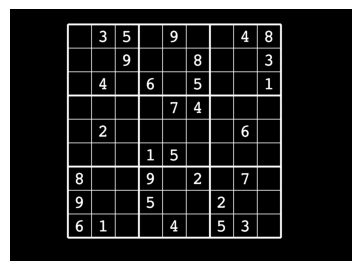

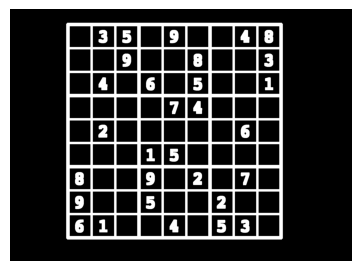

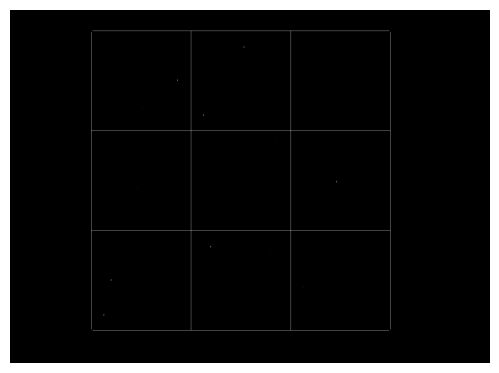

In [65]:
import matplotlib.pyplot

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.imshow(thresh_copy, cmap="gray")
ax.axis("off")

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(132)
ax.imshow(thresh_dialate, cmap="gray")
ax.axis("off")

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(133)
ax.imshow(thresh_erode, cmap="gray")
ax.axis("off")

plt.tight_layout()
plt.show()


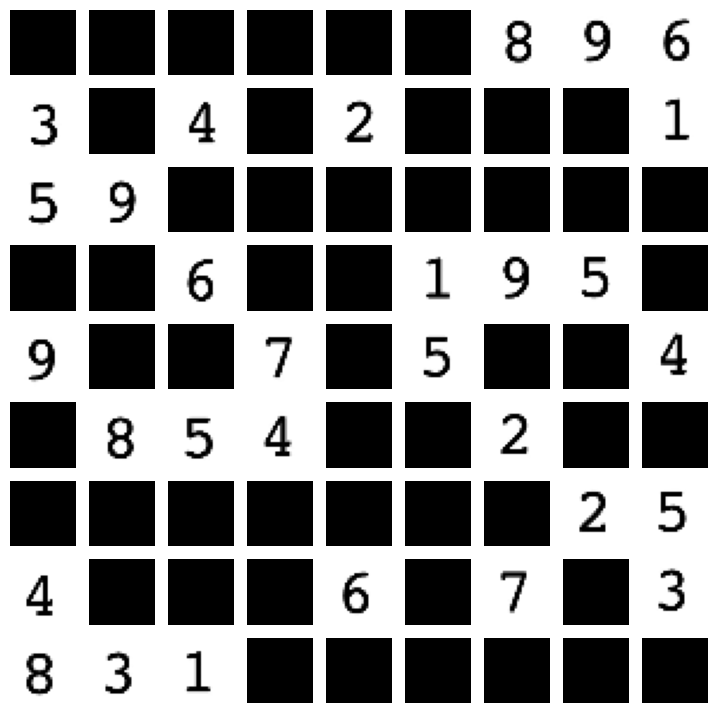

In [80]:
import matplotlib.pyplot as plt

# 9x9のグリッドを作り、各セルに画像をプロット
fig, axs = plt.subplots(9, 9, figsize=(9, 9))

# グリッドをフラットにしてイテレーションを行いやすくする
axs = axs.flatten()

# 各軸（ax）について画像をプロット
for ax, cell in zip(axs, cell_images):
    # ax.imshow(cv2.cvtColor(cell, cv2.COLOR_G)) # BGRからRGBへ変換
    ax.imshow(cell, cmap="gray") # BGRからRGBへ変換
    ax.axis('off')  # 軸の情報をオフにする

plt.show()


# 数字の識別

In [2]:
# データ読み込み
import numpy as np
from sklearn import svm
photos = np.load('../data/samples/28px_10-2.npz')
x = photos['x']/255
y = photos['y']
print(x.shape)
print(y.shape)

# SVMで学習
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=1)
clf = svm.SVC()
clf.fit(X_train, y_train)

(1560, 784)
(1560,)


SVC()

In [3]:
from sklearn import metrics

# 予測の実行
predicted = clf.predict(X_test)
print(f"Classification report for classifier {clf}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")


Classification report for classifier SVC():
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        26
           1       0.97      0.95      0.96        37
           2       0.89      1.00      0.94        24
           3       0.97      0.88      0.92        32
           4       0.97      0.94      0.95        32
           5       0.77      0.74      0.75        31
           6       0.78      0.86      0.82        29
           7       0.91      0.97      0.94        31
           8       0.88      0.81      0.85        37
           9       0.85      0.88      0.87        33

    accuracy                           0.89       312
   macro avg       0.89      0.90      0.90       312
weighted avg       0.90      0.89      0.89       312


In [16]:

print(type(X_test))
print(X_test.shape)
print(X_test[0])


<class 'numpy.ndarray'>
(312, 784)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 

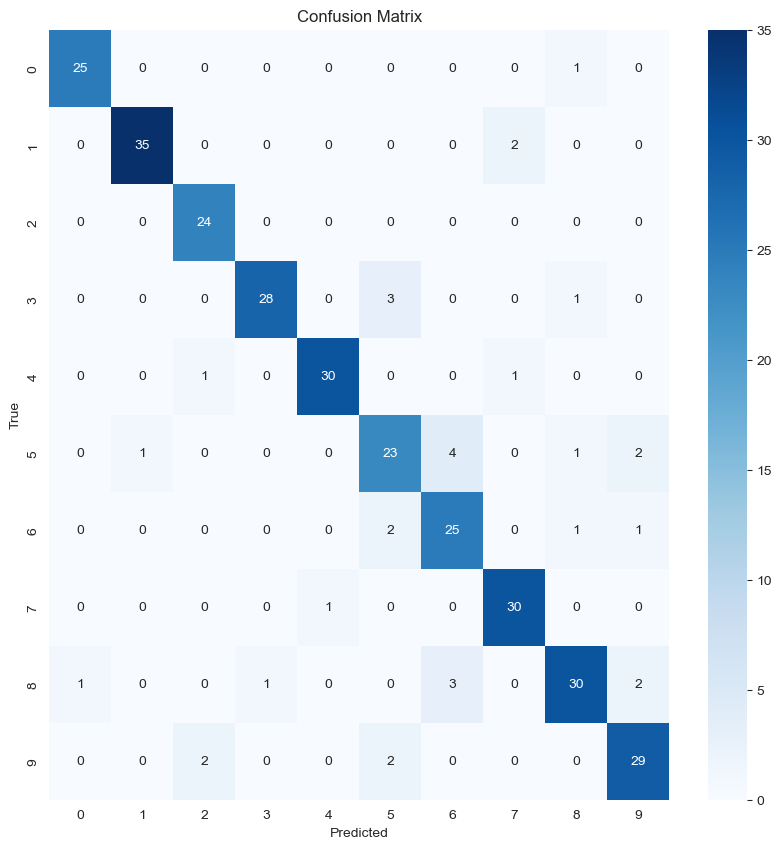

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 混同行列の可視化
conf_mat = metrics.confusion_matrix(y_test, predicted)
plt.figure(figsize=(10, 10))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## マス抽出&数字識別

In [84]:
# import cv2
# import numpy as np
# 
# import cv2
# filename = "../data/level1/sample.jpg"
# img = cv2.imread(filename, cv2.IMREAD_COLOR)
# if img is None:
#     raise IOError("FaileRd to load image: {:s}".format(filename))
# 
# # 二値データに変換
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)
# 
# # 輪郭を見つける
# contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# 
# # 9x9の格子の外枠を見つける（最も大きな輪郭と想定）
# largest_contour = max(contours, key=cv2.contourArea)
# 
# # マス目の輪郭の四角を描く
# x, y, w, h = cv2.boundingRect(largest_contour)
# 
# # 各マス目の画像を抽出し、リストに保存
# cell_images = []
# stepx = w // 9
# stepy = h // 9
# for i in range(9):
#     for j in range(9):
#         cell = img[y + j*stepy:y + (j+1)*stepy, x + i*stepx:x + (i+1)*stepx]
#         resized_cell = cv2.resize(cell, (28, 28))
#         # [修正・追加] グレースケールと正規化
#         gray_cell = cv2.cvtColor(resized_cell, cv2.COLOR_BGR2GRAY)
#         normalized_cell = gray_cell / 255.0
#         # [修正・追加] フラット化 or モデルに合わせたreshape（ここでは一例として(28, 28, 1)にreshape）
#         input_data = normalized_cell.reshape((28, 28, 1))  # モデルの入力形状に合わせてreshapeすること。
#         cell_images.append(input_data)

# [追加] np.arrayに変換してモデル入力用データとする
model_input = np.array(cell_images)

# モデル入力を2次元に変換
model_input_2d = model_input.reshape(model_input.shape[0], -1)
# 予測
predicted = clf.predict(model_input_2d) 


In [85]:
import numpy as np
filename = "../data/level1/sample.txt"
correct_labels = correct_labels = np.loadtxt(filename, dtype=int)

# 正解データと予測データを1次元に変換
correct_labels_flat = correct_labels.flatten()
predicted_labels_flat = predicted.flatten()

# 正解ラベルが0でない場所（数独でいう埋めるべき場所）のインデックスを取得
nonzero_indices = np.where(correct_labels_flat != 0)

# 正解ラベルと予測ラベルを、正解ラベルが0でない位置でフィルタリング
filtered_correct_labels = correct_labels_flat[nonzero_indices]
filtered_predicted_labels = predicted_labels_flat[nonzero_indices]

# Accuracyを計算して表示
accuracy = metrics.accuracy_score(filtered_correct_labels, filtered_predicted_labels)
print(f"Accuracy: {accuracy:.2f}")

print(metrics.classification_report(filtered_correct_labels, filtered_predicted_labels))

Accuracy: 0.03
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.05      0.33      0.09         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         5
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         4

    accuracy                           0.03        30
   macro avg       0.01      0.03      0.01        30
weighted avg       0.01      0.03      0.01        30


/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/yuonoda/anaconda3/envs/advml/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
